In [84]:
# 1. Let’s attempt to predict the survival of a horse based on various observed medical conditions. 
# Load the data from ‘horses.csv’ and observe whether it contains missing values. [Hint: Pandas dataframe has a method isnull] 
# 2. This dataset contains many categorical features, replace them with label encoding. 
# [Hint: Refer to get_dummies methods in pandas dataframe or Label encoder in scikit-learn] 
# 3. Replace the missing values with the most frequent value in each column. [Hint: Refer to Imputer class in Scikit learn preprocessing module] 
# 4. Fit a decision tree classifier and observe the accuracy. 
# 5. Fit a random forest classifier and observe the accuracy. 

import seaborn as sns
import matplotlib. pyplot as plt
import pandas as pd

df = pd.read_csv("horse.csv", usecols = ['surgery','age','temp_of_extremities','peripheral_pulse','mucous_membrane', 'rectal_temp','pulse','respiratory_rate','total_protein','abdomo_protein','cp_data'])
#df = df1[['surgery','age','temp_of_extremities','peripheral_pulse','mucous_membrane', 'rectal_temp','pulse','respiratory_rate','total_protein','abdomo_protein','cp_data']]
print(df)
df = df.fillna({'surgery':'.', 'age':'.', 'temp_of_extremities':'.', 'peripheral_pulse':'.', 'mucous_membrane':'.'}).fillna(0)
print(df)

    surgery    age  rectal_temp  pulse  respiratory_rate temp_of_extremities  \
0        no  adult         38.5   66.0              28.0                cool   
1       yes  adult         39.2   88.0              20.0                 NaN   
2        no  adult         38.3   40.0              24.0              normal   
3       yes  young         39.1  164.0              84.0                cold   
4        no  adult         37.3  104.0              35.0                 NaN   
..      ...    ...          ...    ...               ...                 ...   
294     yes  adult          NaN  120.0              70.0                cold   
295      no  adult         37.2   72.0              24.0                cool   
296     yes  adult         37.5   72.0              30.0                cold   
297     yes  adult         36.5  100.0              24.0                cool   
298     yes  adult         37.2   40.0              20.0                 NaN   

    peripheral_pulse mucous_membrane  t

In [86]:
# 2. This dataset contains many categorical features, replace them with label encoding. 
# [Hint: Refer to get_dummies methods in pandas dataframe or Label encoder in scikit-learn] 
# 3. Replace the missing values with the most frequent value in each column. [Hint: Refer to Imputer class in Scikit learn preprocessing module] 
# 4. Fit a decision tree classifier and observe the accuracy. 
# 5. Fit a random forest classifier and observe the accuracy. 

def cm(df,col):
    label_encoder = LabelEncoder()
    c = df[col]
    encoded_data = label_encoder.fit_transform(c)
    df[col] = encoded_data
    #return (encoded_data)

for d in df:
    d1_data = df[d]
    t = type((d1_data[0]))
    if t is str:
        cm(df,d)

<class 'str'>
False
<class 'str'>
False
<class 'numpy.float64'>
False
<class 'numpy.float64'>
False
<class 'numpy.float64'>
False
<class 'str'>
False
<class 'str'>
False
<class 'str'>
False
<class 'numpy.float64'>
False
<class 'numpy.float64'>
False
<class 'str'>
False
     surgery  age  rectal_temp  pulse  respiratory_rate  temp_of_extremities  \
0          0    0         38.5   66.0              28.0                    2   
1          1    0         39.2   88.0              20.0                    0   
2          0    0         38.3   40.0              24.0                    3   
3          1    1         39.1  164.0              84.0                    1   
4          0    0         37.3  104.0              35.0                    0   
..       ...  ...          ...    ...               ...                  ...   
294        1    0          0.0  120.0              70.0                    1   
295        0    0         37.2   72.0              24.0                    2   
296       

In [87]:
# 3. Replace the missing values with the most frequent value in each column. [Hint: Refer to Imputer class in Scikit learn preprocessing module] 
# 4. Fit a decision tree classifier and observe the accuracy. 
# 5. Fit a random forest classifier and observe the accuracy. 
import numpy as np
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="most_frequent")
print(imp.fit_transform(df))

[[ 0.   0.  38.5 ...  8.4  0.   0. ]
 [ 1.   0.  39.2 ... 85.   2.   0. ]
 [ 0.   0.  38.3 ...  6.7  0.   1. ]
 ...
 [ 1.   0.  37.5 ...  6.8  0.   0. ]
 [ 1.   0.  36.5 ...  6.   3.4  1. ]
 [ 1.   0.  37.2 ... 62.   1.   0. ]]


In [88]:
print(df)

     surgery  age  rectal_temp  pulse  respiratory_rate  temp_of_extremities  \
0          0    0         38.5   66.0              28.0                    2   
1          1    0         39.2   88.0              20.0                    0   
2          0    0         38.3   40.0              24.0                    3   
3          1    1         39.1  164.0              84.0                    1   
4          0    0         37.3  104.0              35.0                    0   
..       ...  ...          ...    ...               ...                  ...   
294        1    0          0.0  120.0              70.0                    1   
295        0    0         37.2   72.0              24.0                    2   
296        1    0         37.5   72.0              30.0                    1   
297        1    0         36.5  100.0              24.0                    2   
298        1    0         37.2   40.0              20.0                    0   

     peripheral_pulse  mucous_membrane 

In [89]:
x = df.iloc[:,1:20]   # variables affecting the label - leaving out address and other strings because they may not affect the label
y = df["cp_data"] # label for prediction
print(x)
print(y)

     age  rectal_temp  pulse  respiratory_rate  temp_of_extremities  \
0      0         38.5   66.0              28.0                    2   
1      0         39.2   88.0              20.0                    0   
2      0         38.3   40.0              24.0                    3   
3      1         39.1  164.0              84.0                    1   
4      0         37.3  104.0              35.0                    0   
..   ...          ...    ...               ...                  ...   
294    0          0.0  120.0              70.0                    1   
295    0         37.2   72.0              24.0                    2   
296    0         37.5   72.0              30.0                    1   
297    0         36.5  100.0              24.0                    2   
298    0         37.2   40.0              20.0                    0   

     peripheral_pulse  mucous_membrane  total_protein  abdomo_protein  
0                   4                0            8.4             0.0  
1  

In [98]:
# 4. Fit a decision tree classifier and observe the accuracy. 
# 5. Fit a random forest classifier and observe the accuracy. 

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

Accuracy :
0.7575757575757576


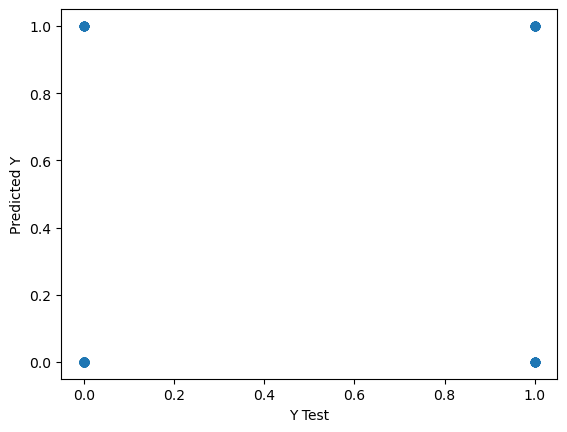

In [99]:
clf = DecisionTreeClassifier(random_state=0)
# Train Decision Tree Classifer
clf = clf.fit(x_train,y_train)
#Predict the response for test dataset
pred_y = clf.predict(x_test)
plt.scatter(y_test,pred_y)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
print("Accuracy :")
acc = accuracy_score(y_test,pred_y)
print(acc)

Accuracy :
0.7777777777777778


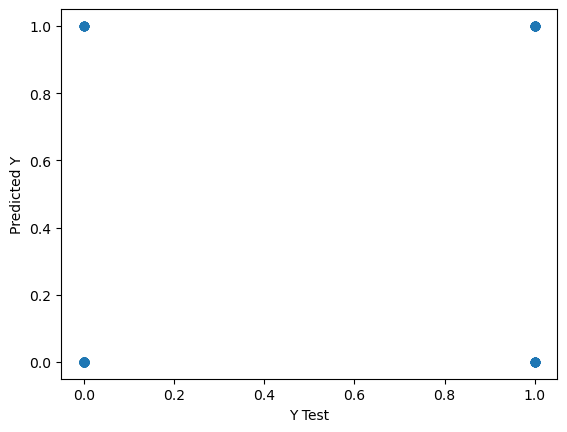

In [100]:
rf = RandomForestClassifier()
# Train Decision Tree Classifer
rf = rf.fit(x_train,y_train)
#Predict the response for test dataset
pred_y = rf.predict(x_test)
plt.scatter(y_test,pred_y)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
print("Accuracy :")
acc = accuracy_score(y_test,pred_y)
print(acc)